# SETUP

Connect to Google Drive to access dataset files

In [ ]:
# Connect to google drive system
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd '/content/drive/MyDrive/ECON3024 Research'

/content/drive/.shortcut-targets-by-id/1tEQB830wHFUYlfCADfe5BKC8A4Lt1Crh/ECON3024 Research


## To teammates:

### Connecting to shared drive folder "ECON3024 Research"

I made a shortcut in my own drive for my own access.

> cd '/content/drive/MyDrive/ECON3024 Research'

In order to access the folder properly, you will need to do the same / rewrite the connecting directory to your own path.

#### **Adding a shortcut to your drive**
Right click the ECON folder > Organize > Add shortcut > find your main drive and add shortcut there.

Run the `cd 'path/to/econfolder'` command (change directory) in the block below.

You MUST keep the block 1 line long to run this console command properly. You cannot run more than 1 command.


If cd command is successful, you should be able to generate a list of files currently in our research folder below using `ls`,
e.g.

'Comments for 10 11 peer ppt .gdoc' <br>
'Comments for 17 10 peer ppt .gdoc' <br>
'Comments for 20 10 peer ppt .gdoc' <br>
 commodity_regression_analysis.ipynb <br>
'Copy of Data processing.ipynb' <br>
 Data/ <br>
'Data processing.ipynb' <br>
'Graphs (raw data + outdated results)'/ <br>
'Research Proposal Presentation.gslides' <br>

In [ ]:
ls

# Data processing

Skip this if you don't need to update the data!

#### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SHOW_DATA_PROCESSING_PLOTS = True

## Trade statistics


### Actual Trade Data

#### Fetching trade data & processing

In [ ]:
country_codes = {
    "BRA": "Brazil",
    "CHN": "China",
    "IND": "India",
    "RUS": "Russian Federation",
    "ZAF": "South Africa",
    "USA": "United States"
}
country_codes_inverse = {v: k for k, v in country_codes.items()}
relevant_country_fields = [
    # " World",
    "Brazil", "China", "India", "Russian Federation", "South Africa"
    , "United States"
]

def fetch_trade_data():
    trade_data_folder_path = "Data/Trades/"
    import_path_prefix = trade_data_folder_path + "Imports_"
    export_path_prefix = trade_data_folder_path + "Exports_"
    trade_dfs = dict()
    # I don't know why there is a space before "World" but whatevs

    import_dfs = []
    export_dfs = []
    for country in country_codes:
        for is_import in range(2):
            filepath = (import_path_prefix if is_import else export_path_prefix) + country + ".csv"
            df = pd.read_csv(filepath)
            df = df[df['Partner Name'].isin(relevant_country_fields)]
            df.drop(columns=['Reporter Name', 'Trade Flow', 'Product Group', 'Indicator'], inplace=True)
            df.set_index('Partner Name', inplace=True)
            df.index.name = None
            df = df.T
            df.index = pd.to_numeric(df.index, errors='coerce')
            df.rename(columns=country_codes_inverse, inplace=True)
            df[country] = 0
            df = df[country_codes.keys()]   # sort
            df = df.ffill()  # JUST FOR RUSSIA
            if is_import:
                import_dfs.append(df)
            else:
                export_dfs.append(df)
    return import_dfs, export_dfs

#### Stacking data into 3 dimensional format


In [ ]:
def stack_trade_dfs(import_dfs, export_dfs):
    # for d in import_dfs:
    #     print(d.shape)
    import_arr3d = np.stack([d.values for d in import_dfs], axis=0)
    import_arr3d = np.transpose(import_arr3d, axes=(1, 0, 2))
    # print(import_arr3d.shape)
    # for d in export_dfs:
    #   print(d.columns, d.shape)
    export_arr3d = np.stack([d.values for d in export_dfs], axis=0)
    export_arr3d = np.transpose(export_arr3d, axes=(1, 0, 2))
    # print(export_arr3d.shape)

    # geometric mean of 2 countries' import/export data
    arr3d = np.power(import_arr3d * export_arr3d, 0.5)
    return arr3d

#### Data processing execution

Note: all fields here are using Thousand USD as unit.

In [ ]:
import_dfs, export_dfs = fetch_trade_data()
export_dfs[3].loc[2022] = export_dfs[3].iloc[-1]  # RUSSIA QUICKFIX (LACKING 2022 DATA)
# print(export_dfs[3])

stacked_trades = stack_trade_dfs(import_dfs, export_dfs)
trade_years = list(import_dfs[0].index.to_numpy())
yi = trade_years.index(2006)
print(trade_years)
print(stacked_trades.shape)
print(stacked_trades[0])


### Gravity model estimation

#### GDP Data

In [ ]:
country_codes = {
    "BRA": "Brazil",
    "CHN": "China",
    "IND": "India",
    "RUS": "Russian Federation",
    "ZAF": "South Africa",
    "USA": "United States"
}
country_codes_inverse = {v: k for k, v in country_codes.items()}

# Fetch GDP data (Annual GDP for BRICS and US (2000-2024).csv)
GDP_csv_path = "Data/GDP/Annual GDP for BRICS and US (2000-2024).csv"
GDP_df = pd.read_csv(GDP_csv_path)
GDP_df.set_index("Country Name", inplace=True)
GDP_df = GDP_df.T
GDP_df.index = [int(i) for i in GDP_df.index]   # for some reason the new csv has Year in string format
GDP_df.index.name = "Year"

# print(GDP_df.head(5))
GDP_df = GDP_df.astype(np.float64)
GDP_df.rename(columns=country_codes_inverse, inplace=True)
GDP_df = GDP_df[list(country_codes.keys())]
print(GDP_df.info())

# values shape (T, n)
vals = GDP_df.to_numpy()
# compute outer product for each year: result shape (T, n, n)
GDP_products = vals[:, :, None] * vals[:, None, :]
# print(GDP_products)
# sample output
gdp_years = list(GDP_df.index.to_numpy())                 # shape (T,)
countries = GDP_df.columns.to_list()            # length n
year_i = gdp_years.index(2012)    # e.g. 2012
j = countries.index('BRA')
k = countries.index('CHN')
# GDP_products[year_i, j, k]              # numeric product for BRA * CHN in 2012
GDP_products.shape

#### Distance data

In [ ]:
country_codes = {
    "BRA": "Brazil (brasilia)",
    "CHN": "China (Beijing)",
    "IND": "India (new delhi)",
    "RUS": "Russia (moscow)",
    "ZAF": "South Africa (Pretoria)",
    "USA": "US (washington)"
}
country_codes_inverse = {v: k for k, v in country_codes.items()}

# Fetch Distance data
distance_csv_path = "Data/Geographical Distance/BRICS geographical distance_fixed.csv"
distance_df = pd.read_csv(distance_csv_path)
distance_df.set_index('from/to', inplace=True)
distance_df.index.name = None
# Rename headers
distance_df.rename(columns=country_codes_inverse, inplace=True)
distance_df = distance_df[country_codes.keys()]
distance_df = distance_df.T
distance_df.rename(columns=country_codes_inverse, inplace=True)
distance_df = distance_df[country_codes.keys()]
distance_df = distance_df.T
# Convert to numeric format
distance_df.replace(',', '', regex=True, inplace=True)
distance_df = distance_df.apply(pd.to_numeric, errors='coerce')
distance_df = distance_df * 1000  # Try to use meters

distance_df.fillna(np.inf, inplace=True)
distance_df

,BRA,CHN,IND,RUS,ZAF,USA
BRA,inf,16934000.0,14243000.0,11166000.0,7901000.0,6774000.0
CHN,16934000.0,inf,3786000.0,5810000.0,11652000.0,11171000.0
IND,14243000.0,3786000.0,inf,4346000.0,7976000.0,12068000.0
RUS,11166000.0,5810000.0,4346000.0,inf,9074000.0,8408000.0
ZAF,7901000.0,11652000.0,7976000.0,9074000.0,inf,13029000.0
USA,6774000.0,11171000.0,12068000.0,8408000.0,13029000.0,inf


#### Predicted trade statistics

In [ ]:
distance_vals = distance_df.to_numpy()
predTrade = GDP_products / distance_vals / distance_vals
# predTrade[list(gdp_years).index(2001)]

### Parallel calculations (gravity model multiplier terms) + aligning data years

In [ ]:
# stacked_trades
print(min(trade_years), max(trade_years))
# predTrade
print(min(gdp_years), max(gdp_years))

# our effective year range (that is available from both GDP & trades)
year_range = (max(min(gdp_years), min(trade_years)), min(max(gdp_years), max(trade_years)))
print(stacked_trades.shape, predTrade.shape)

# calc gravity multiplier
gravity_multiplier = stacked_trades[trade_years.index(year_range[0]):trade_years.index(year_range[1])+1] \
    / predTrade[gdp_years.index(year_range[0]):gdp_years.index(year_range[1])+1]
gravity_multiplier[np.isnan(gravity_multiplier)] = 1
gravity_multiplier = np.log(gravity_multiplier)
gravity_multiplier[gravity_multiplier == np.inf] = 0
gravity_multiplier[gravity_multiplier == -np.inf] = 0
print(gravity_multiplier.shape)
print(gravity_multiplier[0])
print(gravity_multiplier.shape[-1])

### Gravity model multiplier mean (without USA)

#### Calculations (without USA)

In [ ]:
temp = gravity_multiplier[:, :-1, :-1]
gravity_means = np.sum(temp, axis=(1, 2)) / temp.shape[-1] / (temp.shape[-1] - 1)
gravity_stds = np.nanstd(np.where(temp==0, np.nan, temp), ddof=1, axis=(1, 2))

# TURNING LOG VALUES BACK TO NORMAL
# BECAUSE GRAVITY MODEL COINTEGRATION FAILED ALL OF US
# gravity_means = np.exp(gravity_means)
# THIS WAS A MISTAKE IT DIDNT WORK OF COURSE IT DIDNT

print(gravity_means)
print(gravity_stds)

output_path_mean = "Data/Cleaned data/Intra-BRICS Trade mean.csv"
output_path_std = "Data/Cleaned data/Intra-BRICS Trade std.csv"

gravity_means_df = pd.DataFrame({'Intra-BRICS Trade mean': gravity_means}, index=np.arange(year_range[0], year_range[1]+1))
from scipy.stats.mstats import winsorize
gravity_means_df['Intra-BRICS Trade mean'] = winsorize(gravity_means_df['Intra-BRICS Trade mean'], limits=[0.01, 0.01])
gravity_means_df.index.name = "Year"
gravity_means_df.to_csv(
    output_path_mean,
    index=True
)
gravity_stds_df = pd.DataFrame({'Intra-BRICS Trade std': gravity_stds}, index=np.arange(year_range[0], year_range[1]+1))
gravity_stds_df.index.name = "Year"
gravity_stds_df.to_csv(
    output_path_std,
    index=True
)

[-8.54753637 -8.41581995 -8.24016035 -8.45974528 -8.57596709 -8.60674585
 -8.72569192 -8.87864285 -8.81745312 -8.92207354 -9.10466793 -9.19427828
 -9.14628869 -9.18131448 -9.1937016  -9.09264108 -9.19011616 -9.26453475
 -9.25114053 -9.27812809 -9.14619416 -9.16085523 -9.2022859 ]
[0.8840293  1.04480303 0.9793536  1.10588781 1.16888366 1.14503788
 1.17466392 1.22885312 1.20591858 1.09064027 1.24168525 1.30645241
 1.29164927 1.30684955 1.28486366 1.21049408 1.16010872 1.16145389
 1.17257706 1.19024317 1.21943613 1.26176472 1.34000489]


#### Visualization (mean)

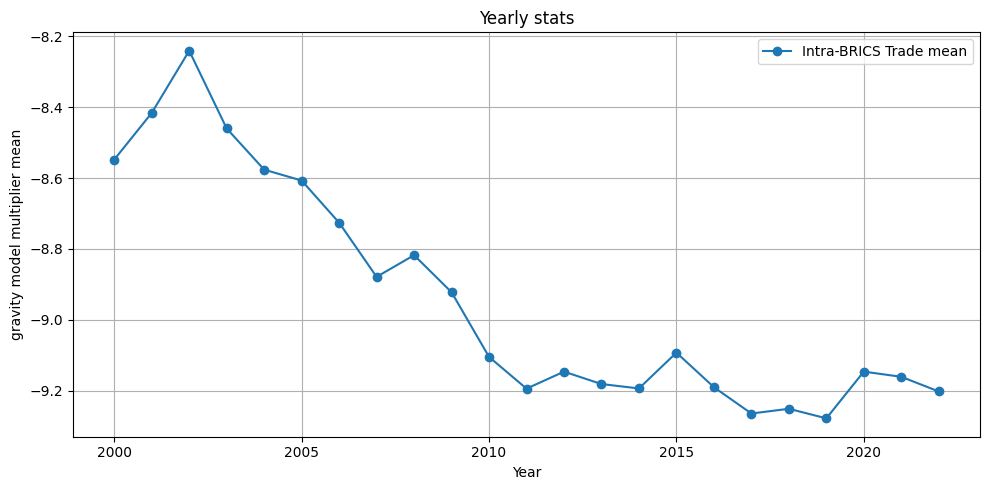

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = gravity_means_df.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("gravity model multiplier mean")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/gravity multiplier means plot.png", dpi=150)
plt.show()

#### Visualization (std)

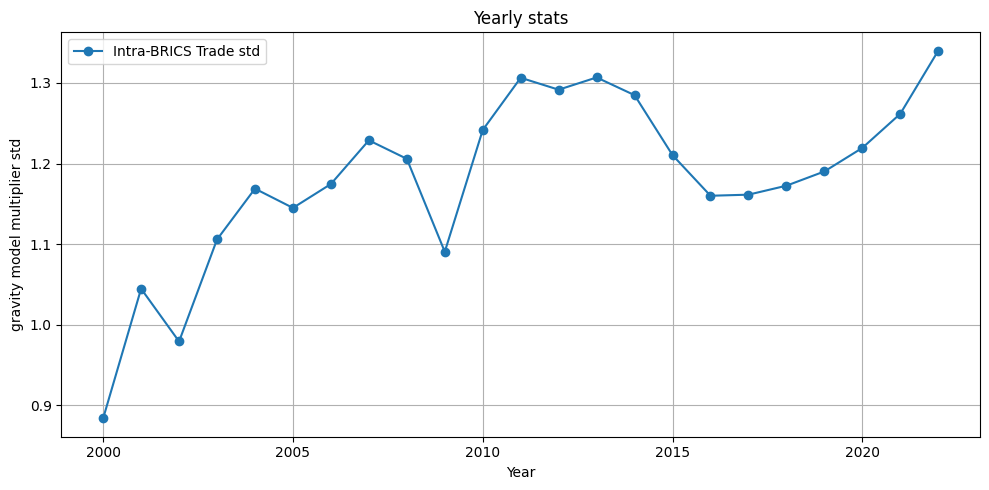

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = gravity_stds_df.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("gravity model multiplier std")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/gravity multiplier stds plot.png", dpi=150)
plt.show()

### Gravity model multiplier statistics (with respect to USA)

#### Calculations (with respect to USA)

In [ ]:
# Geometric mean for
# gravity_multipliers_usa = np.power(gravity_multiplier[:, -1, :-1] * gravity_multiplier[:, :-1, -1], 0.5)
gravity_multipliers_usa = (gravity_multiplier[:, -1, :-1] + gravity_multiplier[:, :-1, -1]) / 2
# print(gravity_multipliers_usa)

# Find mean & SD
gravity_multipliers_usa_mean = np.mean(gravity_multipliers_usa, axis=1)
gravity_multipliers_usa_std = np.std(gravity_multipliers_usa, axis=1)
print(gravity_multipliers_usa_mean)
print(gravity_multipliers_usa_std)

# gravity multiplier statistics with respect to USA
output_path_mean = "Data/Cleaned data/BRICS-USA Trade mean.csv"
output_path_std = "Data/Cleaned data/BRICS-USA Trade std.csv"

gravity_usa_means_df = pd.DataFrame({'BRICS-USA Trade mean': gravity_multipliers_usa_mean}, index=np.arange(year_range[0], year_range[1]+1))
gravity_usa_means_df.index.name = "Year"
gravity_usa_means_df.to_csv(
    output_path_mean,
    index=True
)
gravity_usa_stds_df = pd.DataFrame({'BRICS-USA Trade std': gravity_multipliers_usa_std}, index=np.arange(year_range[0], year_range[1]+1))
gravity_usa_stds_df.index.name = "Year"
gravity_usa_stds_df.to_csv(
    output_path_std,
    index=True
)

[-8.60132573 -8.58938256 -8.6254949  -8.73898262 -8.80560234 -8.89521438
 -8.91988907 -9.01885267 -8.96670382 -9.24120952 -9.26772445 -9.25991228
 -9.29066511 -9.35504744 -9.40761063 -9.4367635  -9.50654124 -9.56189948
 -9.57457526 -9.64107564 -9.62634874 -9.5709034  -9.76145088]
[0.579754   0.62240859 0.64759618 0.68708875 0.71866308 0.76186456
 0.80421356 0.84358652 0.80971251 0.7620962  0.80331079 0.79900165
 0.79996249 0.81837684 0.77681402 0.71491977 0.6815163  0.6836279
 0.66230988 0.63514676 0.67200513 0.65268804 0.92427705]


#### Visualization (mean wrt USA)

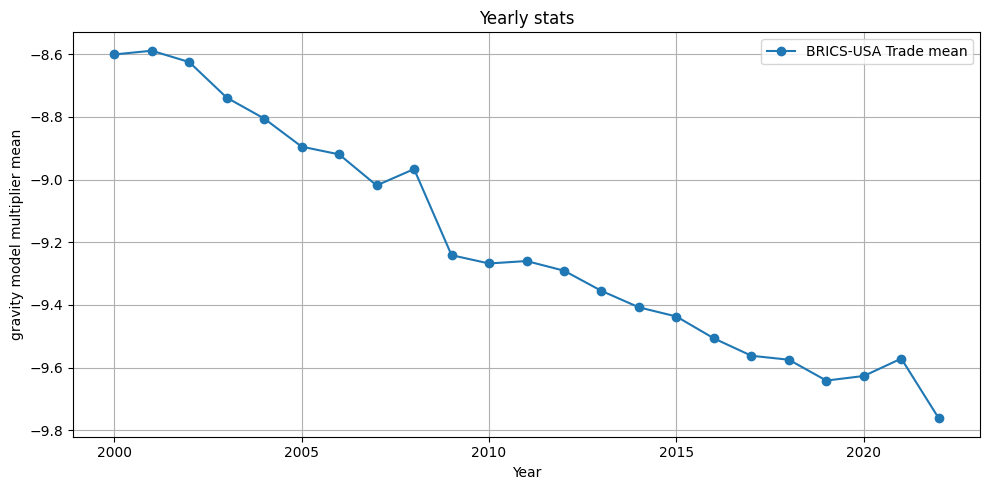

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = gravity_usa_means_df.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("gravity model multiplier mean")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/gravity multiplier means wrt USA plot.png", dpi=150)
plt.show()

#### Visualization (std wrt USA)

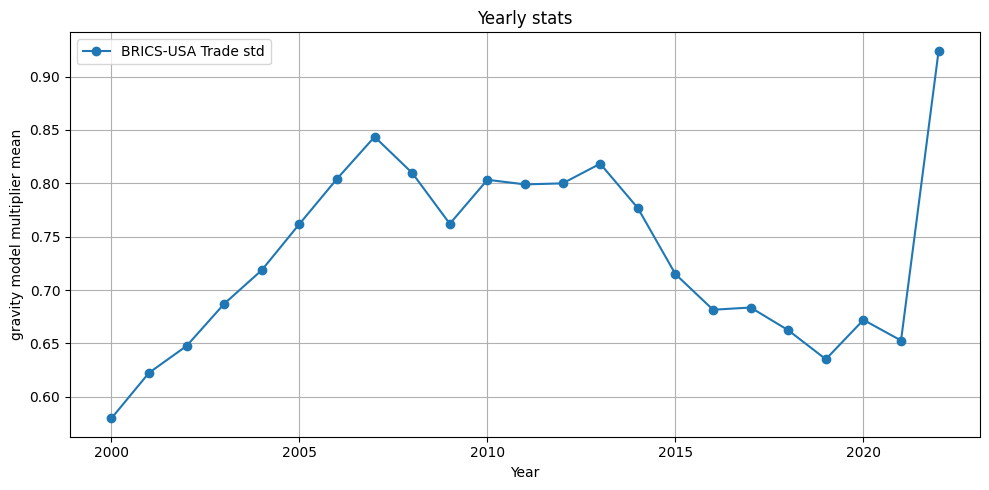

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = gravity_usa_stds_df.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("gravity model multiplier mean")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/gravity multiplier stds wrt USA plot.png", dpi=150)
plt.show()

## Commodity prices (Oil & Gas)


### Commodity price data

#### Fetch & process commodity price data

In [ ]:
commodities_folder_path = "Data/Import: Oil & Gas/"
country_codes = {
    "BRA": "Brazil",
    "CHN": "China",
    "IND": "India",
    "RUS": "Russia",
    "ZAF": "South Africa",
    # "USA": "United States"
}
country_codes_inverse = {v: k for k, v in country_codes.items()}
relevant_country_fields = [
    "Brazil", "China", "India", "Russia", "South Africa"
    # , "United States"
]
year_range = (2000, 2023)

def fetch_commodity_data():
    oil_path_prefix = commodities_folder_path + "/Oil/crude petroleum oil (2023-2010)/"
    gas_path_prefix = commodities_folder_path + "/Gas/"

    oil_df = pd.DataFrame(columns=country_codes.keys())
    oil_df.index.name = "Year"
    gas_df = pd.DataFrame(columns=country_codes.keys())
    gas_df.index.name = "Year"
    for year in np.arange(year_range[0], year_range[1]+1):
        for is_oil in range(2):
            filepath = (oil_path_prefix if is_oil else gas_path_prefix) + str(year) + ".csv"
            df = pd.read_csv(filepath)
            df = df[["Country ID", "Product share in the country's total imports (%)"]]
            df.set_index("Country ID", inplace=True)
            # print(df)
            df = df.loc[country_codes.keys()].T
            if is_oil:
                oil_df.loc[int(year)] = df.iloc[-1]
            else:
                gas_df.loc[int(year)] = df.iloc[-1]

    oil_df = oil_df.add(gas_df)
    return oil_df

#### Calculations

In [ ]:
commodity_df = fetch_commodity_data()

output_path = "Data/Cleaned data/commodity product import share.csv"

commodity_df.to_csv(
    output_path,
    index=True
)

#### Visualization

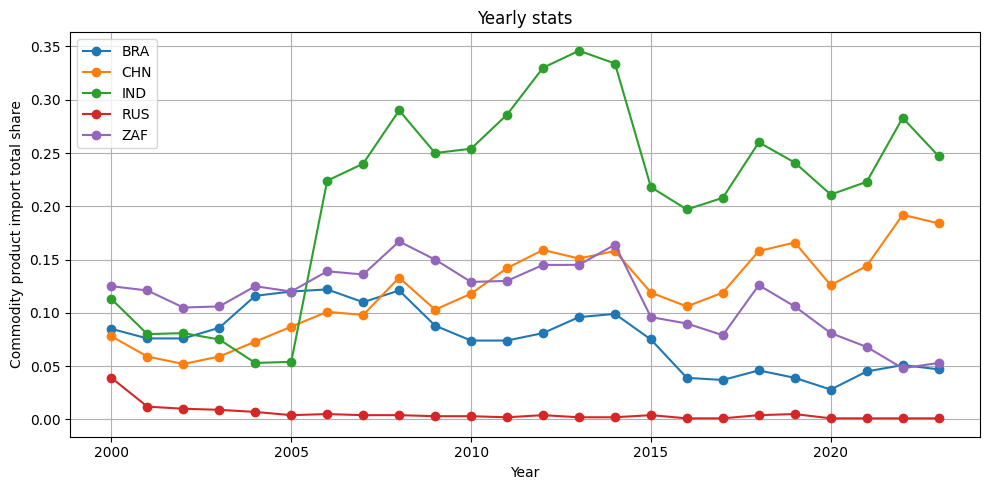

In [ ]:
# assume df is your stats DataFrame with Year as index
if SHOW_DATA_PROCESSING_PLOTS:
    ax = commodity_df.plot(kind='line', figsize=(10, 5), marker='o')
    ax.set_title("Yearly stats")
    ax.set_xlabel("Year")
    ax.set_ylabel("Commodity product import total share")
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(r"Data/Cleaned data/commodity product import share plot.png", dpi=150)
    plt.show()

### Metrics (mean & standard deviation)

#### Calculations

In [ ]:
commodity_means = commodity_df.mean(axis=1)
commodity_stds = commodity_df.std(axis=1)
# print(commodity_means)
# print(commodity_stds)

output_path_mean = "Data/Cleaned data/commodity product import share mean (non-weighted).csv"
output_path_std = "Data/Cleaned data/commodity product import share std (non-weighted).csv"

commodity_means_df = pd.DataFrame({'Commodity mean': commodity_means}, index=np.arange(year_range[0], year_range[1]+1))
commodity_means_df.index.name = "Year"
commodity_means_df.to_csv(
    output_path_mean,
    index=True
)
commodity_stds_df = pd.DataFrame({'Commodity std': commodity_stds}, index=np.arange(year_range[0], year_range[1]+1))
commodity_stds_df.index.name = "Year"
commodity_stds_df.to_csv(
    output_path_std,
    index=True
)
print(commodity_means_df)
print(commodity_stds_df)

      Commodity mean
Year                
2000          0.0880
2001          0.0696
2002          0.0648
2003          0.0670
2004          0.0748
2005          0.0770
2006          0.1182
2007          0.1176
2008          0.1430
2009          0.1188
2010          0.1156
2011          0.1268
2012          0.1438
2013          0.1480
2014          0.1514
2015          0.1024
2016          0.0866
2017          0.0888
2018          0.1188
2019          0.1114
2020          0.0894
2021          0.0962
2022          0.1150
2023          0.1064
      Commodity std
Year               
2000       0.033556
2001       0.039437
2002       0.035954
2003       0.036654
2004       0.048200
2005       0.049132
2006       0.078662
2007       0.084657
2008       0.102579
2009       0.090547
2010       0.091855
2011       0.104820
2012       0.120821
2013       0.125740
2014       0.121049
2015       0.077642
2016       0.074447
2017       0.080014
2018       0.100006
2019       0.095354
2020       0.0

#### Visualization (mean)

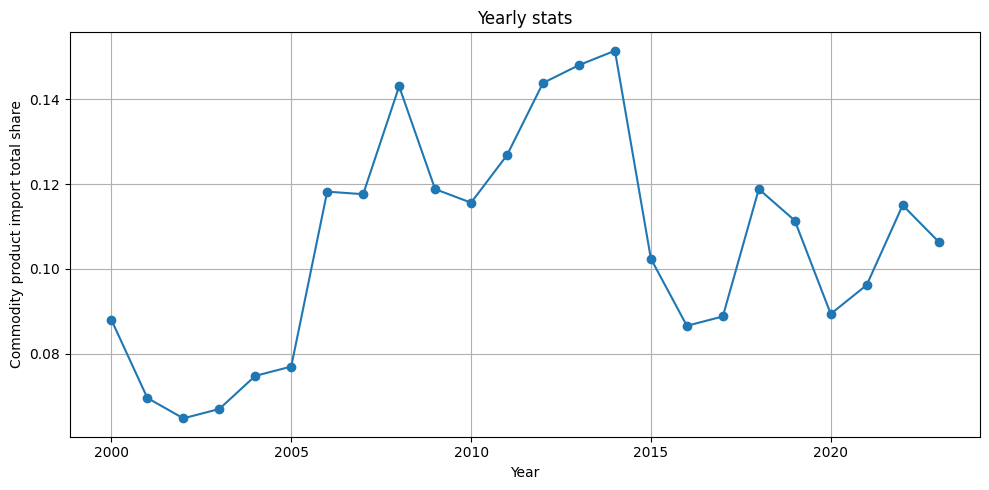

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = commodity_means.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("Commodity product import total share")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/commodity product import share mean (non-weighted) plot.png", dpi=150)
plt.show()

#### Visualization (std)

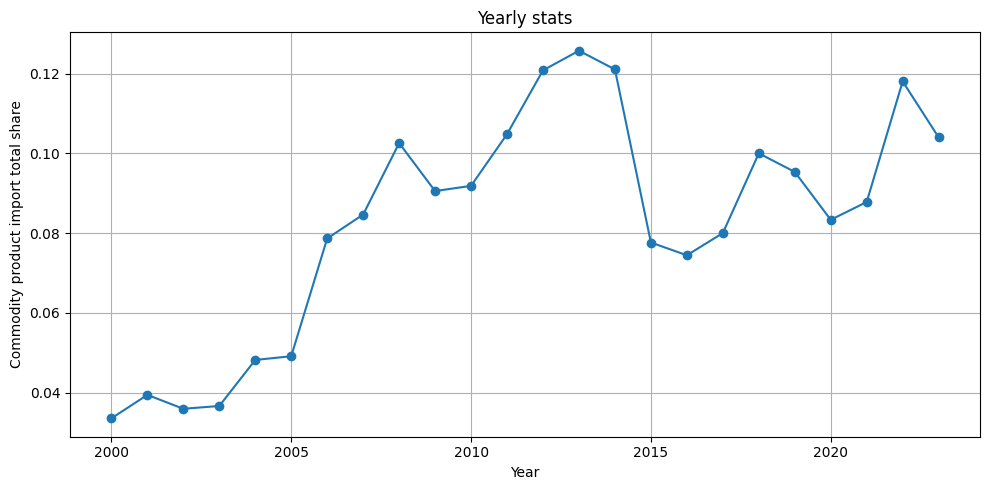

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = commodity_stds.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("Commodity product import total share")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/commodity product import share std (non-weighted) plot.png", dpi=150)
plt.show()

## Unemployment rates

https://ourworldindata.org/grapher/unemployment-rate?tab=table


#### Fetch & process unemployment rate data

In [ ]:
unemployment_filepath = "Data/Unemployment/unemployment-rate_edited.csv"

year_range = (2000, 2023)

def fetch_unemployment_rates():
    unemployment_df = pd.read_csv(unemployment_filepath)
    unemployment_df.set_index("Country Code", inplace=True)
    unemployment_df = unemployment_df.T
    unemployment_df.index = unemployment_df.index.astype(int)
    unemployment_df.index.name = "Year"
    # unemployment_df["Year"] = unemployment_df["Year"].astype(int)
    # unemployment_df.set_index("Year", inplace=True)
    print(unemployment_df.head())

    unemployment_df = unemployment_df[(unemployment_df.index >= year_range[0]) & (unemployment_df.index <= year_range[1])]

    return unemployment_df

#### Calculations

In [ ]:
unemployment_df = fetch_unemployment_rates()

# Find mean & SD
unemployment_rates_means = np.mean(unemployment_df, axis=1)
unemployment_rates_stds = np.std(unemployment_df, axis=1)
# print(unemployment_rates_mean_df)
# print(unemployment_rates_std_df)

# gravity multiplier statistics with respect to USA
output_folder = "Data/Cleaned data/"
output_path_mean = output_folder + "unemployment rate mean.csv"
output_path_std = output_folder + "unemployment rate std.csv"

unemployment_rates_mean_df = pd.DataFrame({'unemployment rate mean': unemployment_rates_means}, index=np.arange(year_range[0], year_range[1]+1))
unemployment_rates_mean_df.index.name = "Year"
unemployment_rates_mean_df.to_csv(
    output_path_mean,
    index=True
)
unemployment_rates_std_df = pd.DataFrame({'unemployment rate std': unemployment_rates_stds}, index=np.arange(year_range[0], year_range[1]+1))
unemployment_rates_std_df.index.name = "Year"
unemployment_rates_std_df.to_csv(
    output_path_std,
    index=True
)

Country Code     BRA     RUS    IND   CHN     ZAF
Year                                             
2000          10.889  10.581  7.624  3.26  22.714
2001          10.649   8.978  7.653  3.80  22.605
2002          10.641   7.875  7.753  4.24  22.547
2003          11.168   8.210  7.680  4.58  22.629
2004          10.072   7.763  7.625  4.49  22.538


#### Visualization (mean)

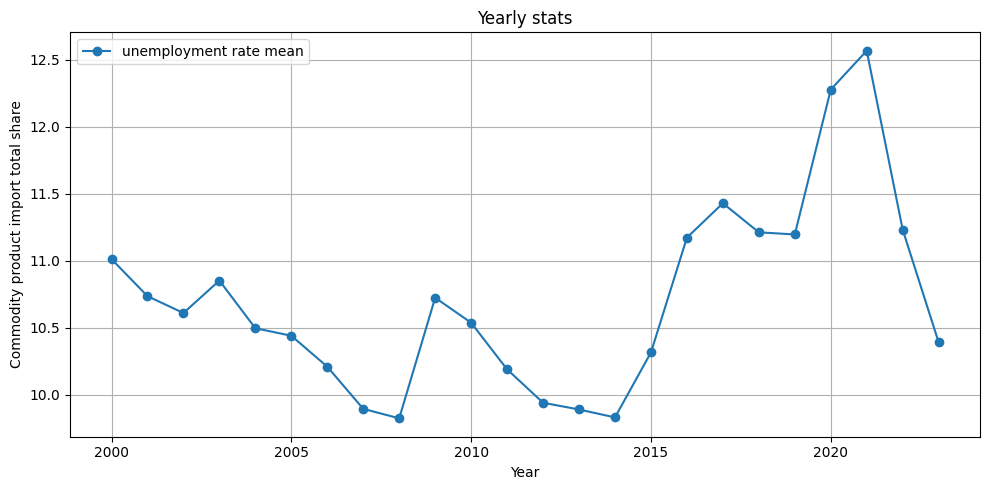

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = unemployment_rates_mean_df.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("Commodity product import total share")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/unemployment rate mean plot.png", dpi=150)
plt.show()

#### Visualization (std)

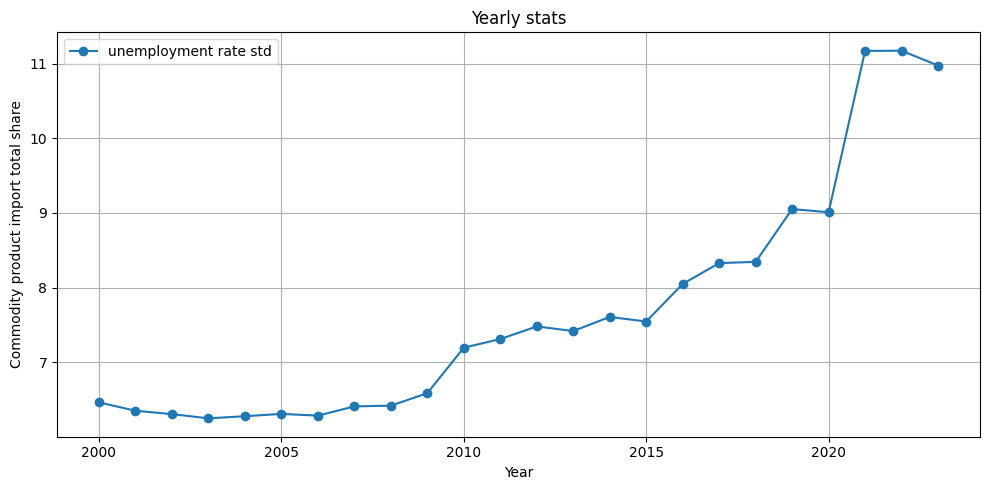

In [ ]:
# assume df is your stats DataFrame with Year as index
ax = unemployment_rates_std_df.plot(kind='line', figsize=(10, 5), marker='o')
ax.set_title("Yearly stats")
ax.set_xlabel("Year")
ax.set_ylabel("Commodity product import total share")
ax.grid(True)
plt.tight_layout()
plt.savefig(r"Data/Cleaned data/unemployment rate std plot.png", dpi=150)
plt.show()

## Unemployment gap

#### Fetch & process unemployment gap data

In [ ]:
unemployment_filepath = "Data/Unemployment/all-in-one backup excel - Unemployment x2.csv"
# country_codes = {
#     "BRA": "Brazil",
#     "CHN": "China",
#     "IND": "India",
#     "RUS": "Russia",
#     "ZAF": "South Africa",
#     # "USA": "United States"
# }
# country_codes_inverse = {v: k for k, v in country_codes.items()}
year_range = (2000, 2020)

# def fetch_unemployment_rates():
#     unemployment_df = pd.read_csv(unemployment_filepath)

#     unemployment_df = unemployment_df.pivot_table(
#         index='Year', columns='Code',
#         values='Unemployment, total (% of total labor force) (modeled ILO estimate)',
#         aggfunc='first'
#     )[country_codes.keys()]
#     unemployment_df = unemployment_df[(unemployment_df.index >= year_range[0]) & (unemployment_df.index <= year_range[1])]

#     return unemployment_df

def fetch_unemployment_gaps():
    unemployment_df = pd.read_csv(unemployment_filepath)
    unemployment_df["Year"] = unemployment_df["Year"].astype(int)
    unemployment_df.set_index("Year", inplace=True)
    # unemployment_df["Year"] = unemployment_df["Year"].astype(int)
    # unemployment_df.set_index("Year", inplace=True)
    unemployment_df = unemployment_df[["U_gap_mean", "U_gap_std"]]
    unemployment_df.rename(columns={"U_gap_mean": "Unemployment gap mean", "U_gap_std": "Unemployment gap std"}, inplace=True)
    print(unemployment_df.head())

    unemployment_df = unemployment_df[(unemployment_df.index >= year_range[0]) & (unemployment_df.index <= year_range[1])]
    return unemployment_df


output_folder = "Data/Cleaned data/"
output_path_mean = output_folder + "Unemployment gap mean.csv"
output_path_std = output_folder + "Unemployment gap std.csv"

unemployment_df = fetch_unemployment_gaps()
unemployment_df["Unemployment gap mean"].to_csv(
    output_path_mean,
    index=True
)
unemployment_df["Unemployment gap std"].to_csv(
    output_path_std,
    index=True
)

      Unemployment gap mean  Unemployment gap std
Year                                             
2000               0.070637              0.319760
2001               0.041770              0.190621
2002               0.030394              0.103292
2003               0.065111              0.117651
2004               0.023366              0.088470


# Regression Model

Last boss

## Setup

### Imports

In [ ]:
import pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests as _multitest
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ardl import ARDL, ardl_select_order
from scipy.stats import boxcox

### Configuration & Variable set definition

In [ ]:
y_col = 'Inflation std'

# ("predictor", flip?, transformation (selected later))
# flipping is only for visualization purposes
testing_set = [
    ('Intra-BRICS Trade mean', -1, 'detrend_diff2'),
    # ('Intra-BRICS Trade mean', -1, 'detrend'),
    # ('Intra-BRICS Trade std', 0),
    ('BRICS-USA Trade mean', -1, 'detrend_diff2'),
    # ('BRICS-USA Trade mean', -1, 'detrend'),
    # ('BRICS-USA Trade std', -1, 'detrend'),
    # ('commodity mean', -1, 'base'),
    ('Commodity std', -1, 'log1p_detrend'),
    ("Unemployment gap mean", 0, 'detrend_boxcox1p_2'),
    # ("Unemployment gap mean", 0, 'base'),

    # ("Unemployment gap std", 0, 'base'),
]
final_set = [
    ('Intra-BRICS Trade mean', 0, 'detrend_diff2'),
    ('BRICS-USA Trade mean', 0, 'detrend_diff2'),
    ('Commodity std', -1, 'log1p_detrend'),
    ("Unemployment gap mean", 0, 'base'),
]

use_testing_set = False
detrend_inflation = False
replot_all_transformation = False

### Data refetching & processing

#### Data fetching

In [ ]:
# --- CONFIGURE ---
folder_path = "Data/Cleaned data/"
out_dir = "Data/Regression outputs/"
files = [
    # "unemployment rate std.csv",
    # "unemployment rate mean.csv",
    "Intra-BRICS Trade mean.csv",
    # "Intra-BRICS Trade std.csv",
    "BRICS-USA Trade mean.csv",
    "BRICS-USA Trade std.csv",
    # "commodity product import share mean (non-weighted).csv",
    "commodity product import share std (non-weighted).csv",
    "Unemployment gap mean.csv",
    # "Unemployment gap std.csv",
]
column_renames = {
    "BRA": "Brazil",
    "CHN": "China, People's Republic of",
    "IND": "India",
    "RUS": "Russian Federation",
    "ZAF": "South Africa"
}
column_renames_inverse = {v: k for k, v in column_renames.items()}
year_range = (2000, 2020)
predictors = testing_set if use_testing_set else final_set
preds = [p[0] for p in predictors]

inflation_filepath = "Data/BRICS inflation data.xlsx"
inflation_sheetname = "Inf BRICS (2000-2025)"


def fetch_all_data():
    df = pd.DataFrame()
    for f in files:
        temp = pd.read_csv(folder_path + f)
        df = pd.concat([df, temp], axis=1)
    df = df.loc[:,~df.columns.duplicated()].copy()  # removes duplicated "Year" columns
    df.set_index("Year", inplace=True)
    inflation_file = pd.ExcelFile(inflation_filepath)
    filedata = inflation_file.parse(inflation_sheetname)
    filedata.drop([0, 6, 7], inplace=True)  # blank rows
    filedata.rename(
        columns={"Inflation rate, average consumer prices (Annual percent change)": "Country"},
        inplace=True
    )
    filedata.set_index("Country", inplace=True)
    filedata = filedata.T
    filedata.index.name = "Year"
    filedata.rename(columns=column_renames_inverse, inplace=True)
    inflation_std = filedata.std(axis=1)

    df = pd.concat([df, inflation_std], axis=1)
    df.rename(columns={0: y_col}, inplace=True)
    df = df[(df.index <= year_range[1]) & (df.index >= year_range[0])]
    df = df[preds + [y_col]]
    df.index = df.index.astype(int)
    return df


def fb(df, col, year):
    if year_range[1] >= year:
        df[col][year] = df[col][year-1]


def data_apply_fallback(df):
    # Special fallback cases
    fb(df, 'BRICS-USA Trade std', 2022)
    fb(df, 'Unemployment gap mean', 2020)
    return df

#### Data processing

In [ ]:
df = fetch_all_data()
df = data_apply_fallback(df)
df.to_csv('Data/Selected data features.csv', index=True)
# df

/tmp/ipython-input-3451985550.py:62: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[col][year] = df[col][year-1]


#### Visualization (untransformed)

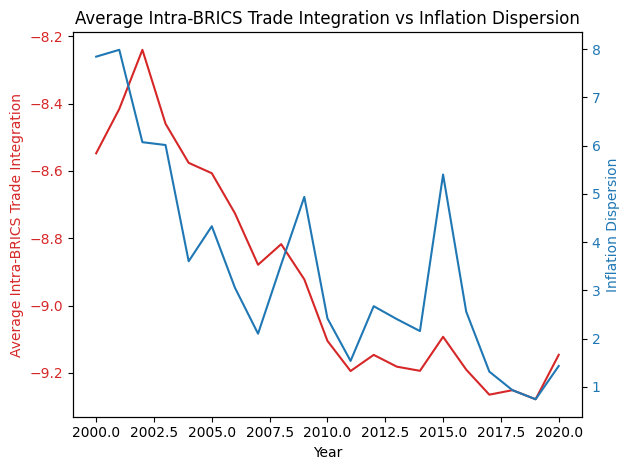

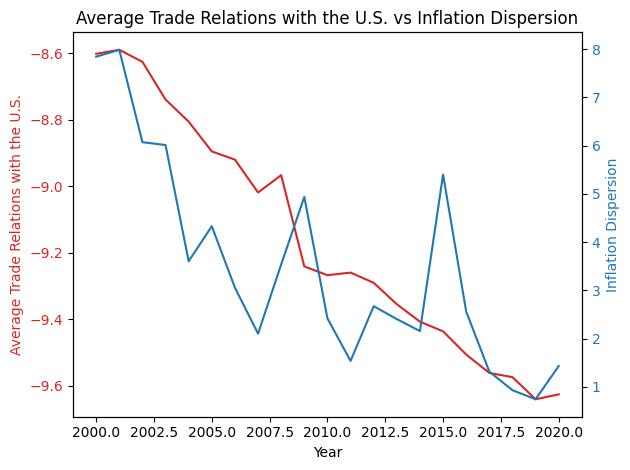

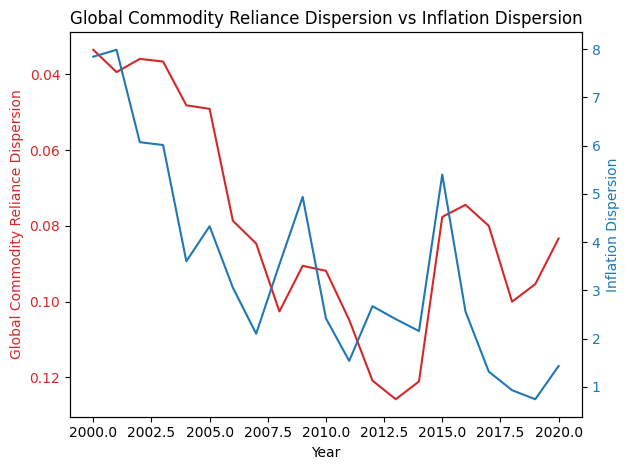

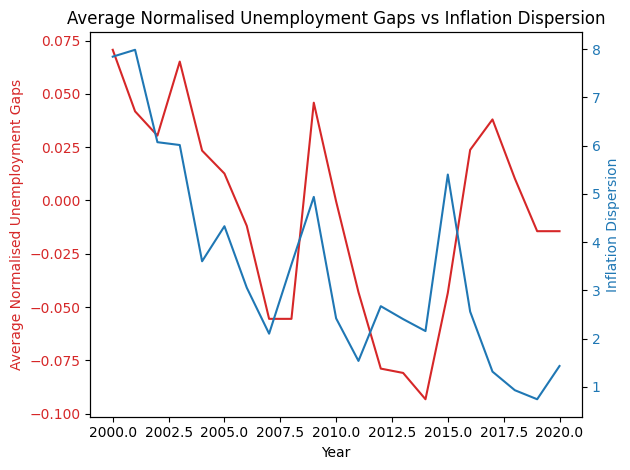

In [ ]:
plot_path = "Data/Regression outputs/against inflation/"
# sns.reset_orig()

df_translate = {
    "Inflation std": "Inflation Dispersion",
    "Intra-BRICS Trade mean": "Average Intra-BRICS Trade Integration",
    "Unemployment gap mean": "Average Normalised Unemployment Gaps",
    "Commodity std": "Global Commodity Reliance Dispersion",
    "BRICS-USA Trade mean": "Average Trade Relations with the U.S."
}

def plot_individual_data(x_col, y_col, df, flipped=False, tfm="base"):
    # 1. Generate dummy data with different scales
    x = df.index.to_list()
    y1 = df[x_col].to_list()
    y2 = df[y_col].to_list()
    # 2. Create the figure and first axis
    fig, ax1 = plt.subplots()

    if x_col in df_translate:
        x_col = df_translate[x_col]
    if y_col in df_translate:
        y_col = df_translate[y_col]

    # 3. Plot the first data on the left y-axis
    color1 = 'tab:red'
    ax1.set_xlabel(df.index.name)
    ax1.set_ylabel(x_col+("" if tfm == "base" else " ("+tfm+")"), color=color1)
    ax1.plot(x, y1, color=color1)
    ax1.tick_params(axis='y', labelcolor=color1) # Color the ticks to match
    if flipped:
        # print("FLIP!")
        ax1.invert_yaxis()

    # 4. Create the second axis sharing the x-axis
    ax2 = ax1.twinx()
    color2 = 'tab:blue'
    ax2.set_ylabel(y_col, color=color2)
    ax2.plot(x, y2, color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    # plt.gca().invert_yaxis()
    # 6. Show the plot
    plt_title = x_col + " vs " + y_col
    plt.title(plt_title)
    # plt.show()
    fig.tight_layout()  # Prevents the right y-label from being clipped
    plt.savefig(f'{plot_path + plt_title}.png')


for x_col, flipped, _ in predictors:
    plot_individual_data(x_col, y_col, df, flipped=flipped)

## Model & Analytics

### Stationarity

#### ADF Test

In [ ]:
# Unit-root checks (ADF)
def adf_test(series, sig=0.05):
    res = adfuller(series.dropna(), autolag='AIC')
    return {
        "ADF stat": res[0],
        "p-value": res[1],
        "stationary": res[1] < sig
    }

def full_adf_test(df):
    adf_results = [adf_test(df[p]) for p in df.columns]
    adf_df = pd.DataFrame(adf_results, index=df.columns.to_list())
    return adf_df


# interpretation: p < 0.05 -> stationary
adf_df = full_adf_test(df)
adf_df_failed = adf_df[adf_df['stationary'] == False]
# adf_df

#### Helper functions

In [ ]:
def detrend_series(series):
    """Remove a linear trend (fit on non-NaN values) and return detrended series."""
    s = series.dropna()
    if s.empty:
        return s
    x = np.arange(len(s))
    coef = np.polyfit(x, s.values.astype(float), 1)
    trend = np.polyval(coef, x)
    return pd.Series(s.values - trend, index=s.index)

def boxcox_auto(series, plus=0):
    """Finds the best boxcox factor that transforms the given data to resemble a normal distribution."""
    s = series.dropna()
    if s.empty:
        return s
    s = s + plus
    if (s < 0).sum() > 0:
        # There exists negative values, error.
        return s
    transformed_data, optimal_lambda = boxcox(s.to_numpy())
    return pd.Series(transformed_data, index=s.index)

def boxcox_manual(series, plus=0, l=0):
    """Apply desired boxcox transformation manually."""
    s = series.dropna()
    if s.empty:
        return s
    s = s + plus
    if (s < 0).sum() > 0 and l != 2 and l != 4:
        # There exists negative values, error.
        return s
    if l == 0:
        transformed_data = np.log(s)
    else:
        transformed_data = (np.power(s, l) - 1) / l
    return pd.Series(transformed_data, index=s.index)



def simple_plot(ts):
    plt.figure(figsize=(10, 4))
    ts.plot(title='Time Series: '+ts.name, color='blue', linewidth=1)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Transformations

In [ ]:
transformations = {
    "base": lambda s: s,
    "diff1": lambda s: s.diff(1),
    "diff2": lambda s: s.diff(2),
    "log": lambda s: np.log(s),
    "log_diff1": lambda s: np.log(s).diff(1),
    "log_diff2": lambda s: np.log(s).diff(2),
    # detrending options
    "detrend": lambda s: detrend_series(s),
    "detrend_diff1": lambda s: detrend_series(s).diff(1),
    "detrend_diff2": lambda s: detrend_series(s).diff(2),
    "log_detrend": lambda s: detrend_series(np.log(s)),
    "log_detrend_diff1": lambda s: detrend_series(np.log(s)).diff(1),
    "log_detrend_diff2": lambda s: detrend_series(np.log(s)).diff(2),
    # fallbacks for zeros/negatives
    "log1p": lambda s: np.log1p(s),
    "log1p_diff1": lambda s: np.log1p(s).diff(1),
    "log1p_diff2": lambda s: np.log1p(s).diff(2),
    "log1p_detrend": lambda s: detrend_series(np.log1p(s)),
    "log1p_detrend_diff1": lambda s: detrend_series(np.log1p(s)).diff(1),
    "log1p_detrend_diff1": lambda s: detrend_series(np.log1p(s)).diff(2),
    # "log1p"
    "boxcox_auto": lambda s: boxcox_auto(s),
    "boxcox1p_auto": lambda s: boxcox_auto(s, 1),
    "boxcox1p_0.5": lambda s: boxcox_manual(s, 1, 0.5),
    "boxcox1p_2": lambda s: boxcox_manual(s, 1, 2),
    "detrend_boxcox1p_2": lambda s: boxcox_manual(detrend_series(s), 1, 1),
}

#### Function: Evaluate stationarity (p-value)

In [ ]:
def try_transformations(series, sig=0.05, tryall=False):
    """Try a sequence of transformations and return the first that passes ADF."""
    # print("TRY:", series.name)

    bestres = adf_test(series.dropna(), sig=sig)
    best_fn = "Base"
    p_data = {}
    best_boxcox_factor = None
    for name, fn in transformations.items():
        try:
            ts = fn(series)
        except Exception:
            # print(Exception)
            pass
            continue
        boxcox_factor = None
        if isinstance(ts, tuple):
            ts, boxcox_factor = ts
        ts = ts.dropna()
        if ts.empty:
            continue
        res = adf_test(ts, sig=sig)
        p_data[name] = res["p-value"]
        if not tryall and res["stationary"]:
            return {
                "transformation": name,
                "adf_stat": res["ADF stat"],
                "pvalue": res["p-value"],
                "series": ts,
                "boxcox_factor": boxcox_factor
            }
        else:
            if res["p-value"] < bestres["p-value"]:
                bestres = res
                best_fn = name
                best_boxcox_factor = boxcox_factor
            if res["p-value"] > sig and res["p-value"] < 2*sig:  # Close!
                print("Almost!", {"series": series.name, "transformation": name, "pvalue": res["p-value"]})


    # nothing passed, give best results (see how close it was?)
    best_transformation = {
        "transformation": best_fn,
        "adf_stat": bestres["ADF stat"],
        "pvalue": bestres["p-value"],
        "series": series.dropna(),
        "boxcox_factor": None
    }
    if best_fn[:6] == boxcox:
        best_transformation["boxcox_factor"] = best_boxcox_factor
    return best_transformation, p_data


def augment_adf_with_transforms(df, sig=0.05, tryall=False):
    """
    Run ADF for all columns, try transformations for failing series, and
    return a DataFrame that merges original ADF results with transformation info,
    plus a dict of transformed series (if any).
    """
    # original ADF results (index = column names)
    adf_df = full_adf_test(df)

    # collect transform results for failed series
    results = {}
    rows = []
    p_data_all = {}
    for col in adf_df.index:
        # out = try_transformations(df[col], sig=sig)
        if tryall or not adf_df.loc[col, "stationary"]:
            out, p_data_all[col] = try_transformations(df[col], sig=sig, tryall=tryall)
            results[col] = out  # contains transformed 'series' if found (or original)
            rows.append({
                "series": col,
                "transformation": out["transformation"],
                "transformed_adf_stat": out["adf_stat"],
                "transformed_pvalue": out["pvalue"],
                # "passed_finally": out["transformation"] is not None
                "passed_finally": out["pvalue"] < sig
            })

    if rows:
        transforms_df = pd.DataFrame(rows).set_index("series")
    else:
        # empty DataFrame with expected columns so join works
        transforms_df = pd.DataFrame(columns=[
            "transformation", "transformed_adf_stat", "transformed_pvalue", "passed_finally"
        ])

    merged = adf_df.join(transforms_df)
    merged["passed_finally"] = merged["passed_finally"].fillna(False) | merged["stationary"].fillna(False)

    return merged, results, p_data_all


adf_df, results, p_data_all = augment_adf_with_transforms(df, 0.05, tryall=True)


Almost! {'series': 'Intra-BRICS Trade mean', 'transformation': 'diff1', 'pvalue': np.float64(0.05886529644422201)}
Almost! {'series': 'Intra-BRICS Trade mean', 'transformation': 'detrend_diff1', 'pvalue': np.float64(0.05886529644422795)}
Almost! {'series': 'BRICS-USA Trade mean', 'transformation': 'detrend', 'pvalue': np.float64(0.06199601468965065)}
Almost! {'series': 'BRICS-USA Trade mean', 'transformation': 'detrend_boxcox1p_2', 'pvalue': np.float64(0.06199601468965065)}
Almost! {'series': 'Commodity std', 'transformation': 'boxcox_auto', 'pvalue': np.float64(0.06498614876371168)}


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getatt

Almost! {'series': 'Commodity std', 'transformation': 'boxcox1p_2', 'pvalue': np.float64(0.0678702006424656)}
Almost! {'series': 'Unemployment gap mean', 'transformation': 'log', 'pvalue': np.float64(0.06197838596569297)}
Almost! {'series': 'Unemployment gap mean', 'transformation': 'detrend', 'pvalue': np.float64(0.09915209150721338)}
Almost! {'series': 'Unemployment gap mean', 'transformation': 'log1p_detrend', 'pvalue': np.float64(0.09518279053965434)}
Almost! {'series': 'Unemployment gap mean', 'transformation': 'detrend_boxcox1p_2', 'pvalue': np.float64(0.09915209150721388)}


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(uf

#### Function: Evaluate stationarity (manually & graphically)

In [ ]:
def test_transformations_and_plot(predictor, y_col, df, p_data_all, flipped=False, sig=0.05, plot_path="Data/Regression outputs/against inflation/"):
    """
    Test all transformations for a single predictor against y_col, generate ADF summary, and plot transformed data.
    """
    adf_summary = []  # To store ADF results for each transformation

    # Create a 4x4 grid for subplots (adjust rows/cols based on the number of transformations)
    n_transformations = len(transformations)
    ncols = 6
    nrows = (n_transformations + ncols - 1) // ncols  # Calculate rows dynamically
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # print(predictor)
    # print(p_data_all[predictor])
    p_data = p_data_all[predictor]
    for idx, (name, fn) in enumerate(transformations.items()):
        try:
            # Apply transformation to predictor and y_col
            transformed_x = fn(df[predictor])
            y = df[y_col]

            # Drop NaN values, skip if empty
            transformed_x = transformed_x.dropna()
            if transformed_x.empty:
                continue

            adf_pval = p_data[name]

            # Plot the transformed data
            ax1 = axes[idx]
            ax1.plot(transformed_x.index, transformed_x, label=f"{predictor} ({name})", color="tab:red")
            ax1.set_xlabel("Index")
            ax1.set_ylabel(predictor, color="tab:red")
            ax1.tick_params(axis='y', labelcolor="tab:red")
            ax1.set_title(f"{predictor} ({name})", color='green' if adf_pval < sig else 'red')
            if flipped:
                ax1.invert_yaxis()

            # Plot y_col on the secondary axis
            ax2 = ax1.twinx()
            ax2.plot(y.index, y, label=f"{y_col} ({name})", color="tab:blue")
            ax2.set_ylabel(y_col, color="tab:blue")
            ax2.tick_params(axis='y', labelcolor="tab:blue")

        except Exception as e:
            print(f"Error with transformation {name}: {e}")
            continue

    # Adjust layout and save the combined plot
    fig.tight_layout()
    plt.savefig(f"{plot_path}{predictor}_vs_{y_col}_transformations.png")
    plt.show()


def test_transformations_and_plot_all():
    for predictor, flipped, _ in predictors:
        test_transformations_and_plot(predictor, y_col, df, p_data_all, flipped)

#### Evaluation stationarity (p-value)

In [ ]:
adf_df

,ADF stat,p-value,stationary,transformation,transformed_adf_stat,transformed_pvalue,passed_finally
Intra-BRICS Trade mean,-4.508879,0.000190,True,boxcox1p_auto,-4.508879,0.000190,True
BRICS-USA Trade mean,-5.524268,0.000002,True,boxcox1p_auto,-5.524268,0.000002,True
Commodity std,-2.952106,0.039616,True,log_diff1,-23.243810,0.000000,True
Unemployment gap mean,-2.494623,0.116788,False,log_detrend_diff1,-4.247559,0.000547,True
Inflation std,-3.679852,0.004406,True,log_diff2,-4.340115,0.000378,True


#### Evaluate stationarity (manually & graphically)

In [ ]:
if replot_all_transformation:
    test_transformations_and_plot_all()

### Fit & Transform values

#### Apply selected transformation

In [ ]:
tfm_stats = []
for x_col, flipped, tfm in predictors:
    fn = transformations[tfm]
    df[x_col] = fn(df[x_col])
    # print(tfm)
    tfm_stats.append({
        "Variable": x_col,
        "Transformation": tfm,
        "ADF p-value": p_data_all[x_col][tfm]
    })
    # print(x_col, tfm, p_data_all[x_col][tfm])
    # print(p_data_all[predictor][tfm])

if detrend_inflation:
    detrend_fn = transformations["detrend"]
    df[y_col] = detrend_fn(df[y_col])
    tfm_stats.append({
        "Variable": y_col,
        "Transformation": tfm,
        "ADF p-value": p_data_all[y_col][tfm]
    })

df.bfill(inplace=True)
pd.DataFrame(tfm_stats)
# df

,Variable,Transformation,ADF p-value
0,Intra-BRICS Trade mean,detrend_diff2,0.008927
1,BRICS-USA Trade mean,detrend_diff2,0.001727
2,Commodity std,log1p_detrend,0.029366
3,Unemployment gap mean,base,0.116788


#### Visualization

Intra-BRICS Trade mean 0
BRICS-USA Trade mean 0
Commodity std -1
Unemployment gap mean 0


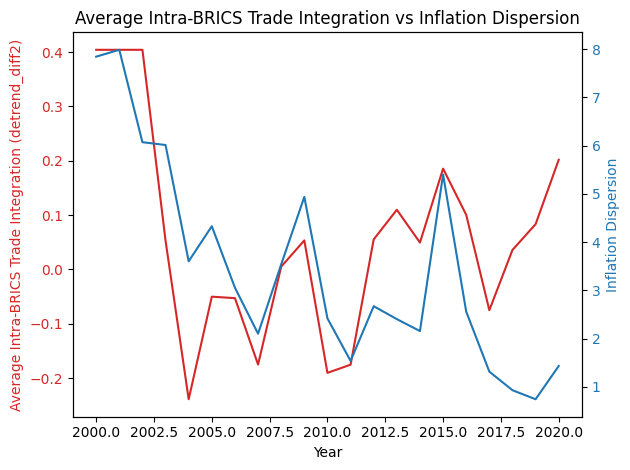

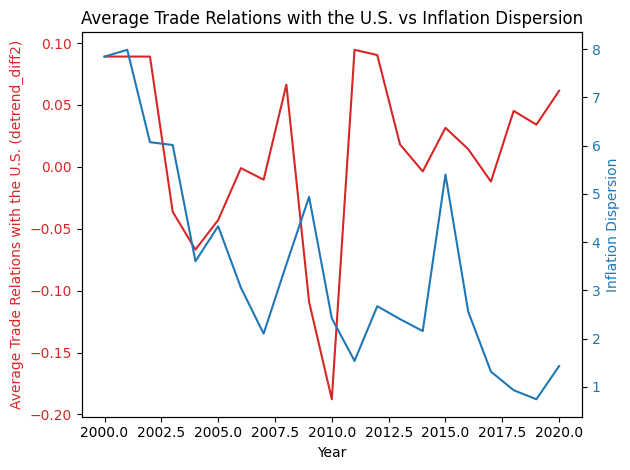

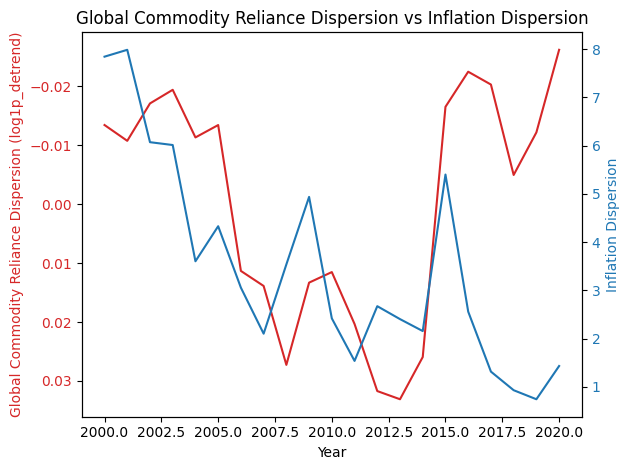

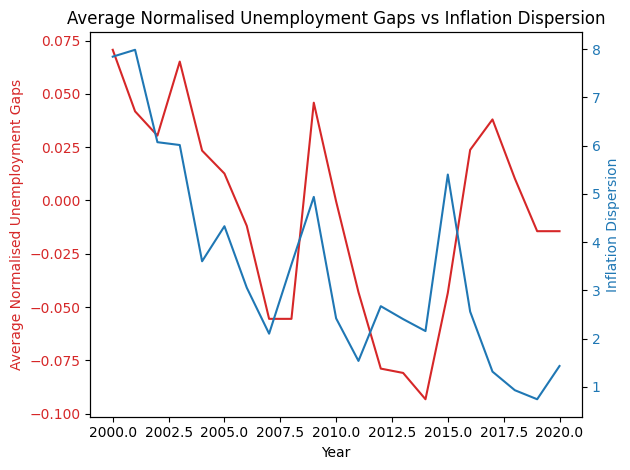

In [ ]:
for x_col, flipped, tfm in predictors:
    plot_individual_data(x_col, y_col, df, flipped, tfm)
    print(x_col, flipped)

### Multicollinearity

#### Correlation Matrix

In [ ]:
def generate_corr_matrix():
    # Calculate the correlation matrix
    temp_df = df[[k for k in df_translate.keys() if k != y_col]].rename(columns=df_translate)
    correlation_matrix = temp_df.corr()

    # Generate the heatmap
    plt.figure(figsize=(10, 8))
    sns.set(font_scale=1)
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap of Predictor Variables')
    plt.tight_layout()  # Adjust layout to prevent shifting
    plt.xticks(rotation=45, ha="right")

    # Save plot
    plot_path = out_dir + "Correlation matrix.png"
    plt.savefig(plot_path, dpi=150, transparent=True)

#### Variance in Factor (VIF)

In [ ]:
# prepare data (drop NA)
def generate_VIF():
    # check multicollinearity (VIF)
    X = df[[k for k in df_translate.keys() if k != y_col]].rename(columns=df_translate)
    # keep const if you want VIF for it, but ignore it in interpretation
    X = sm.add_constant(X)
    vif = pd.DataFrame([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                    index=X.columns)
    vif.drop("const", inplace=True)
    vif.rename(columns={0: "VIF"}, inplace=True)

    # Create the bar chart
    sns.reset_orig()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=vif.index, y="VIF", data=vif)
    # Threshold
    plt.axhline(y=5, color="orange", linestyle="--", label="Threshold: VIF = 5")

    # Customize the plot
    plt.title("Variance Inflation Factor (VIF) Results", fontsize=14)
    plt.ylabel("VIF Value", fontsize=12)
    plt.xlabel("Variable", fontsize=12)
    plt.xticks(rotation=45, ha="right")

    # Save plot
    plot_path = out_dir + "VIF results.png"
    plt.savefig(plot_path, dpi=150, transparent=True)

#### [What Can VIF Tell You?](https://www.investopedia.com/terms/v/variance-inflation-factor.asp)

When Ri2 is equal to 0, and therefore, when VIF or tolerance is equal to 1, the ith independent variable is not correlated to the remaining ones, meaning that multicollinearity does not exist.

In general terms,

- VIF equal to 1 = variables are not correlated
- VIF between 1 and 5 = variables are moderately correlated
- VIF greater than 5 = variables are highly correlated

The higher the VIF, the higher the possibility that multicollinearity exists, and further research is required. When VIF is higher than 10, there is significant multicollinearity that needs to be corrected.

#### Results & Visualization

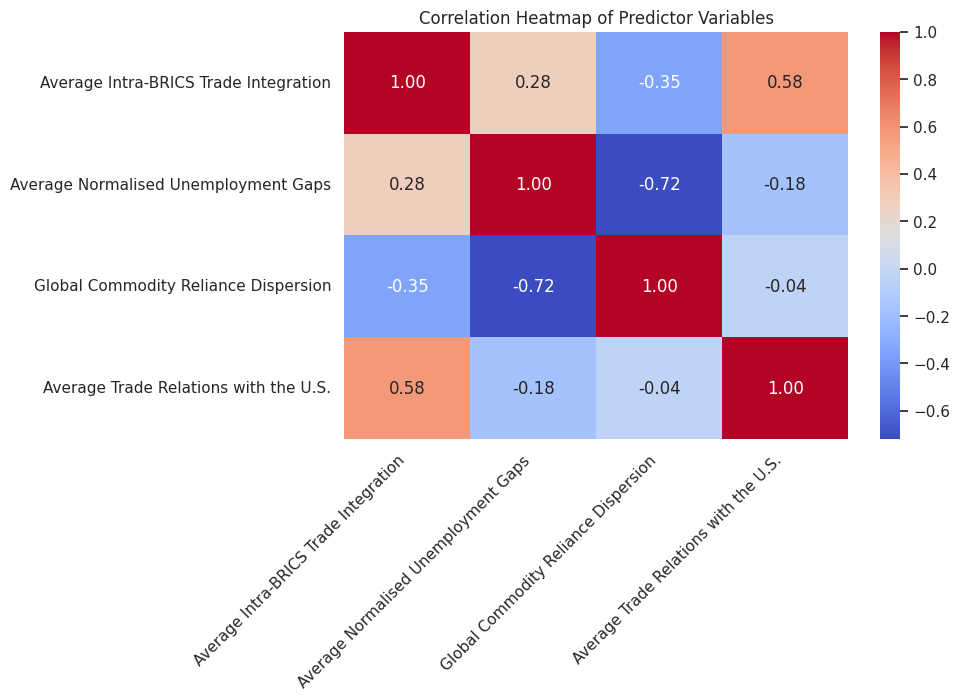

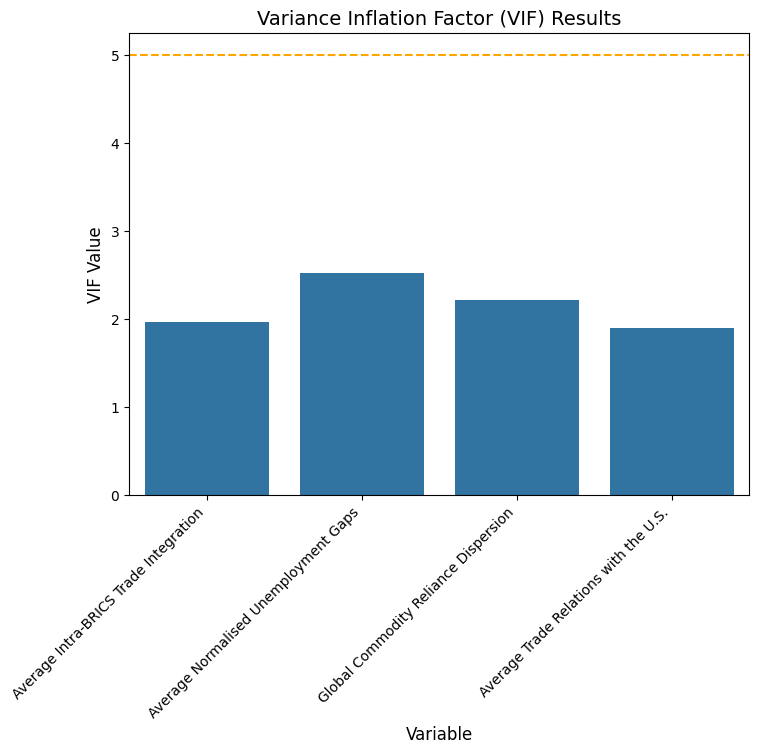

In [ ]:
generate_corr_matrix()
generate_VIF()

### Significance / R2-score (per-predictor OLS)
Only for individual variable analysis. Does not fully represent final model results.

#### OLS

In [ ]:
def generate_indiv_OLS_results():
# --- RUN per-predictor OLS and make plots ---
    rows = []
    dimensions = (3, 2)
    fig, axes = plt.subplots(dimensions[0], dimensions[1], figsize=(20, 12))  # Create a 3x2 grid for 6 plots
    axes = axes.flat  # Flatten the axes array for easy iteration

    for i, x in enumerate(preds):
        sub = df[[y_col, x]].dropna()
        if sub.shape[0] < 3:
            print(f"Skipping {x}: not enough observations ({sub.shape[0]})")
            continue

        y = sub[y_col].astype(float)
        X = sm.add_constant(sub[x].astype(float))

        model = sm.OLS(y, X).fit(cov_type="HC3")  # Robust SEs (HC3)
        pred = model.get_prediction(X)
        pred_df = pred.summary_frame(alpha=0.05)  # mean, mean_ci_lower/upper, obs_ci_...

        # Stats for table
        y_int = model.params.get("const", np.nan)
        coef = model.params.get(x, np.nan)
        se = model.bse.get(x, np.nan)
        t = model.tvalues.get(x, np.nan)
        p = model.pvalues.get(x, np.nan)
        r2 = float(model.rsquared)
        n = int(model.nobs)

        rows.append({
            "predictor": x, "coef": coef,
            "y_intercept": y_int,
            "std_err": se, "t": t,
            "pvalue": p, "r2": r2, "nobs": n
        })

        # PLOT: scatter + fitted line + 95% CI
        ax = axes[i]  # Select subplot
        xs = sub[x].astype(float).values
        order = np.argsort(xs)
        xs_sorted = xs[order]
        mean_pred = pred_df["mean"].values[order]
        ci_low = pred_df["mean_ci_lower"].values[order]
        ci_high = pred_df["mean_ci_upper"].values[order]

        ax.scatter(xs, y, s=18, alpha=0.8, label="data")
        ax.plot(xs_sorted, mean_pred, color="C1", lw=2, label="fitted")
        ax.fill_between(xs_sorted, ci_low, ci_high, color="C1", alpha=0.2, label="95% CI")
        ax.set_xlabel(x)
        ax.set_ylabel(y_col)
        ax.set_title(f"{y_col} ~ {x}")

        # Annotation box
        txt = (
            f"coef = {coef:.4g}\nse = {se:.4g}\nt = {t:.3g}\np = {p:.3g}\n"
            f"R² = {r2:.3f}\nn = {n}"
        )
        ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))
        ax.legend(frameon=False)

    # Adjust layout and save
    plt.tight_layout()
    plot_path = out_dir + "combined_regression_plots.png"
    fig.savefig(plot_path, dpi=150, transparent=False)
    plt.close(fig)

    # --- COLLECT results, adjust p-values, save ---
    indiv_OLS_results = pd.DataFrame(rows).set_index("predictor").sort_values("pvalue")
    if not indiv_OLS_results.empty:
        rej, p_adj, _, _ = _multitest(indiv_OLS_results["pvalue"].fillna(1), method="fdr_bh")
        indiv_OLS_results["p_adj"] = p_adj
        indiv_OLS_results["significant_fdr"] = rej
    indiv_OLS_results.to_csv(out_dir + "univariate_regression_results.csv", float_format="%.6g", index=True)
    print("Done. Outputs saved to:", out_dir)
    return indiv_OLS_results


indiv_OLS_results = generate_indiv_OLS_results()

Done. Outputs saved to: Data/Regression outputs/


#### Visualization (p-value plot)

In [ ]:
# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x="predictor", y="r2", data=indiv_OLS_results)

# Customize the plot
plt.title("R2 score Results", fontsize=14)
plt.ylabel("R2 score", fontsize=12)
plt.xlabel("Variable", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()

# Save plot
plot_path = out_dir + "R2_results.png"
plt.savefig(plot_path, dpi=150, transparent=True)

# Show the plot
plt.show()

### OLS Regression Model

#### Model Summary

In [ ]:
# long-run OLS
# print(df)
sub = df[[y_col] + preds].dropna()
Y = sub[y_col].astype(float)
X = sm.add_constant(sub[preds].astype(float))
model = sm.OLS(Y, X).fit()
print(model.summary())

# Model residuals stationarity check
residuals = model.resid
print(pd.DataFrame(adf_test(residuals), index=["value"]))

#### Visualization of Fitted values & residuals

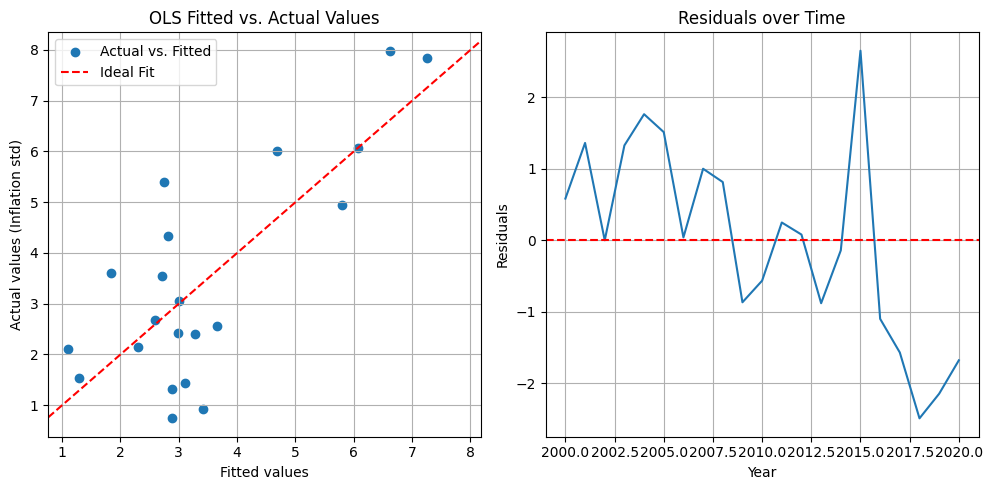

In [ ]:
plot_fitted_values = True
plot_residuals = True
# print(model.params.const)

def plot_OLS(plot_fitted_values=True, plot_residuals=True, figsize=5):
    if not (plot_fitted_values or plot_residuals):
        return
    fig_count = 2 if plot_fitted_values and plot_residuals else 1
    fig, axes = plt.subplots(1, fig_count, figsize=(figsize * fig_count, figsize))
    plotid = 0

    if plot_fitted_values:
        # Plot 1: OLS Fitted vs. Actual Values
        axes[plotid].scatter(model.fittedvalues, sub[y_col], label='Actual vs. Fitted')
        # axes[plotid].plot(sub[y_col], sub[y_col], color='red', linestyle='--', label='Ideal Fit')
        y_col_0 = sub[y_col][year_range[0]]
        axes[plotid].axline((y_col_0, y_col_0), slope=1, color='red', linestyle='--', label='Ideal Fit')
        axes[plotid].set_xlabel('Fitted values')
        axes[plotid].set_ylabel('Actual values (Inflation std)')
        axes[plotid].set_title('OLS Fitted vs. Actual Values')
        axes[plotid].legend()
        axes[plotid].grid(True)
        plotid += 1

    if plot_residuals:
    # Plot 2: Residuals over Time
        axes[plotid].plot(model.resid.index, model.resid)
        axes[plotid].axhline(0, color='red', linestyle='--')
        axes[plotid].set_xlabel('Year')
        axes[plotid].set_ylabel('Residuals')
        axes[plotid].set_title('Residuals over Time')
        axes[plotid].grid(True)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the combined plots
    plot_path = out_dir + "Fitted values & Residuals.png"
    plt.savefig(plot_path, dpi=150, transparent=True)


plot_OLS()

#### Visualization of individual explanatory vs dependent variable

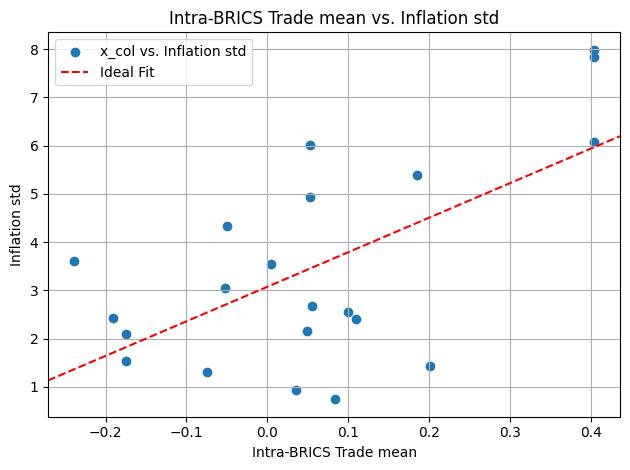

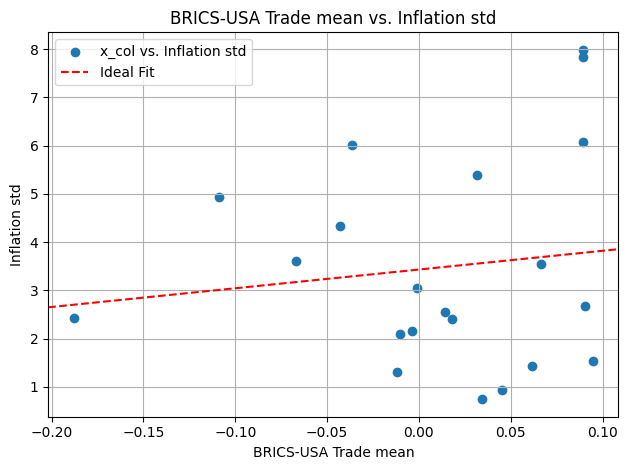

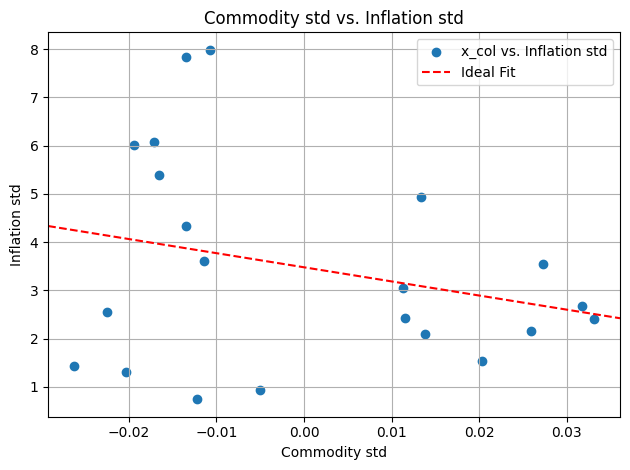

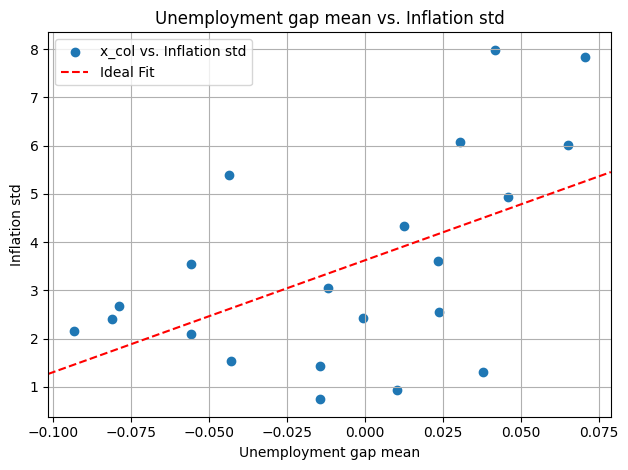

In [ ]:
# print(indiv_OLS_results)

def plot_OLS_individual(df, pred, OLS_results, plot_fitted_values=True, figsize=5):
    fig, ax = plt.subplots()
    # print(f"PLOTTING {pred} against Inflation std...")

    # Plot 1: OLS Fitted vs. Actual Values
    ax.scatter(df[pred], df[y_col], label='x_col vs. Inflation std')
    first_datum = df[pred][year_range[0]]
    ax.axline(
        (first_datum, first_datum * OLS_results["coef"] + OLS_results["y_intercept"]),
        slope=OLS_results["coef"], color='red', linestyle='--', label='Ideal Fit')

    ax.set_xlabel(pred)
    ax.set_ylabel(y_col)
    ax.set_title(f'{pred} vs. {y_col}')
    ax.legend()
    ax.grid(True)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the combined plots
    plot_path = out_dir + f"{pred}.png"
    plt.savefig(plot_path, dpi=150, transparent=True)
    plt.show()


for pred, _, _ in predictors:
    plot_OLS_individual(df, pred, indiv_OLS_results.loc[pred])